# Tracking Movements (Color-based Object Tracking)

Tracks a green-colored object in a video stream and draws its motion trail.

Converted from `track_movement.py` to Jupyter notebook format.

In [1]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

---
## Setup: Tracking Buffer and Color Range

In [2]:
pts = deque(maxlen=64)
kernel = np.ones((5, 5), np.uint8)

Lower_green = np.array([40, 40, 40])
Upper_green = np.array([80, 255, 255])

---
## Option A: Real-time Webcam Tracking (uncomment to run)

This is the live version converted from `track_movement.py`.

In [3]:
# Uncomment and run this cell to start webcam tracking
# Press 'q' to quit

# cap = cv2.VideoCapture(0)
# if not cap.isOpened():
#     print('Cannot open webcam - run the simulation cells below instead')
# else:
#     while True:
#         ret, img = cap.read()
#         if not ret:
#             break
#
#         hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#         mask = cv2.inRange(hsv, Lower_green, Upper_green)
#         mask = cv2.erode(mask, kernel, iterations=2)
#         mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
#         mask = cv2.dilate(mask, kernel, iterations=1)
#         res = cv2.bitwise_and(img, img, mask=mask)
#
#         cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#
#         if len(cnts) > 0:
#             c = max(cnts, key=cv2.contourArea)
#             ((x, y), radius) = cv2.minEnclosingCircle(c)
#             M = cv2.moments(c)
#             center = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00']))
#
#             if radius > 5:
#                 cv2.circle(img, (int(x), int(y)), int(radius), (0, 255, 255), 2)
#                 cv2.circle(img, center, 5, (0, 0, 255), -1)
#                 pts.appendleft(center)
#
#         for i in range(1, len(pts)):
#             if pts[i - 1] is None or pts[i] is None:
#                 continue
#             thick = int(np.sqrt(len(pts) / float(i + 1)) * 2.5)
#             cv2.line(img, pts[i - 1], pts[i], (0, 0, 248), thick)
#
#         cv2.imshow('Frame', img)
#         cv2.imshow('Mask', mask)
#         cv2.imshow('Result', res)
#
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break
#
#     cap.release()
#     cv2.destroyAllWindows()

---
## Option B: Simulate Tracking on a Test Frame

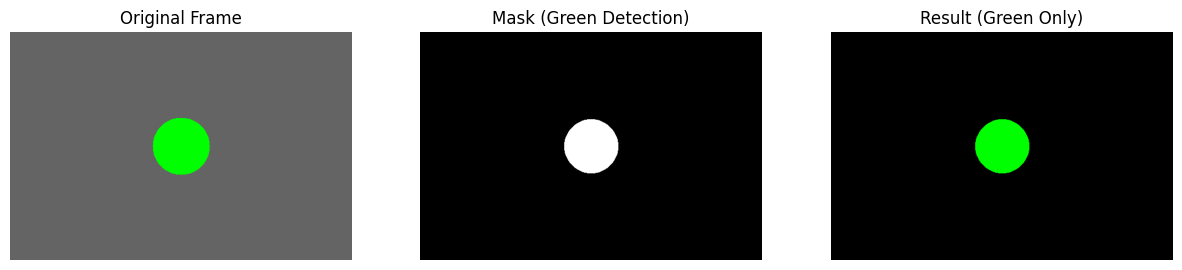

In [4]:
test_frame = np.zeros((400, 600, 3), dtype=np.uint8)
test_frame[:] = (100, 100, 100)
cv2.circle(test_frame, (300, 200), 50, (0, 255, 0), -1)

hsv = cv2.cvtColor(test_frame, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, Lower_green, Upper_green)
mask = cv2.erode(mask, kernel, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.dilate(mask, kernel, iterations=1)
res = cv2.bitwise_and(test_frame, test_frame, mask=mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(test_frame[..., ::-1])
plt.title('Original Frame')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask (Green Detection)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(res[..., ::-1])
plt.title('Result (Green Only)')
plt.axis('off')
plt.show()

---
## Option C: Motion Trail Simulation

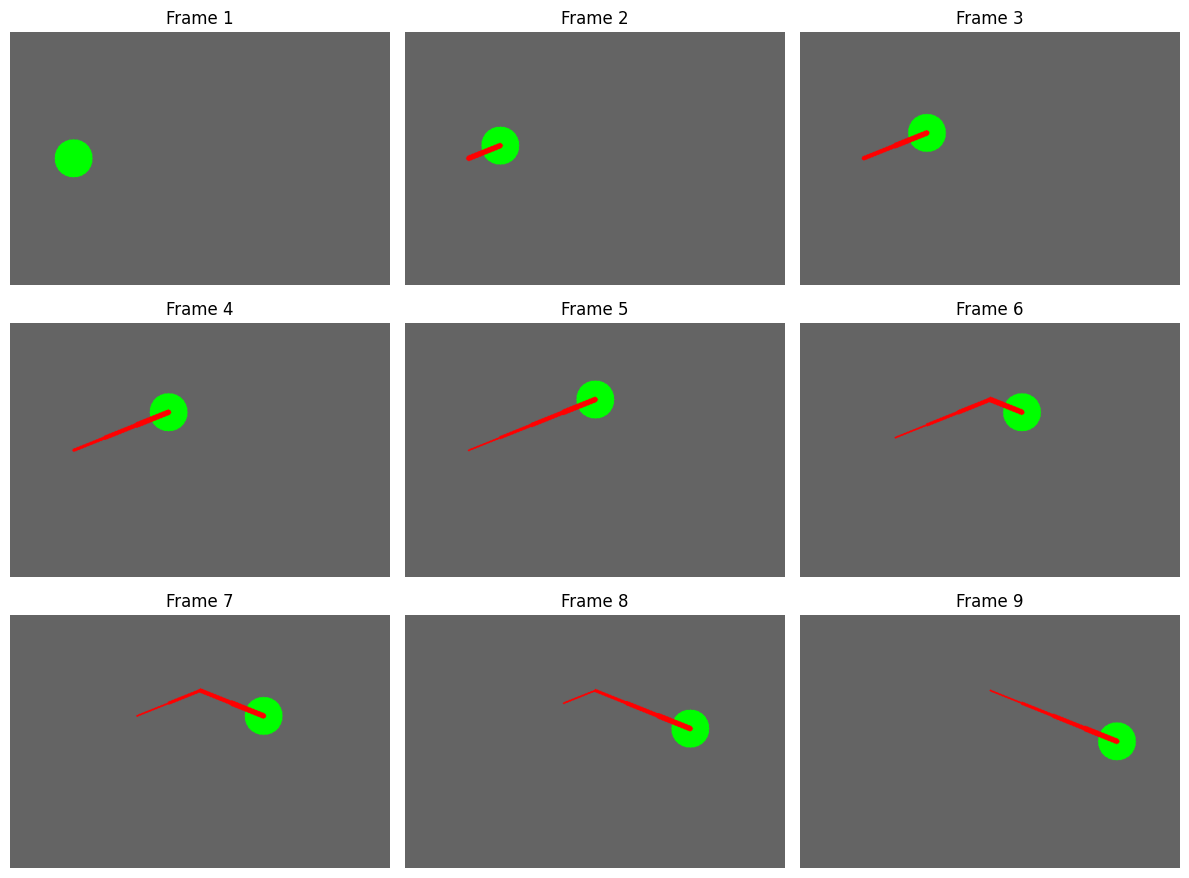

Green dot moves right-to-left with red motion trail


In [5]:
positions = [(100, 200), (150, 180), (200, 160), (250, 140), (300, 120),
             (350, 140), (400, 160), (450, 180), (500, 200)]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, (ax, pos) in enumerate(zip(axes.ravel(), positions)):
    frame = np.zeros((400, 600, 3), dtype=np.uint8)
    frame[:] = (100, 100, 100)
    cv2.circle(frame, pos, 30, (0, 255, 0), -1)

    for j in range(1, min(i + 1, 5)):
        thick = int(10 - j * 2)
        cv2.line(frame, positions[i - j], positions[i - j + 1], (0, 0, 255), thick)

    ax.imshow(frame[..., ::-1])
    ax.set_title(f'Frame {i + 1}')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Green dot moves right-to-left with red motion trail')